In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [4]:
# Load dataset
df = pd.read_csv('exchange_rate.csv')
df['date'] = pd.to_datetime(df['date'], dayfirst=True)
df.set_index('date', inplace=True)

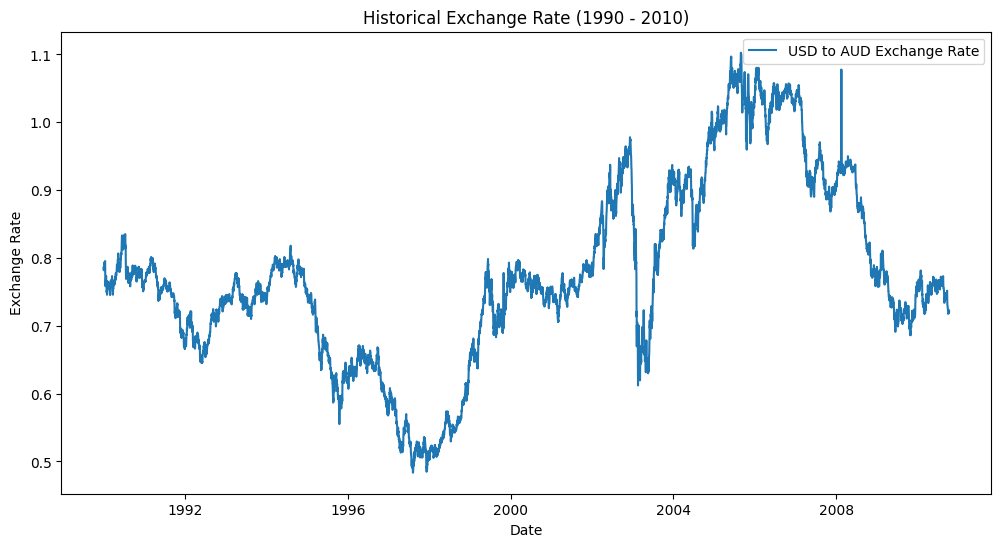

In [5]:
# Plot the time series
plt.figure(figsize=(12, 6))
plt.plot(df['Ex_rate'], label='USD to AUD Exchange Rate')
plt.title('Historical Exchange Rate (1990 - 2010)')
plt.xlabel('Date')
plt.ylabel('Exchange Rate')
plt.legend()
plt.show()

In [6]:
# Check for stationarity
result = adfuller(df['Ex_rate'])
print(f'ADF Statistic: {result[0]:.4f}')
print(f'p-value: {result[1]:.4f}')
# If p-value > 0.05, the data is non-stationary.

ADF Statistic: -1.6650
p-value: 0.4492


In [7]:
# First-order differencing to achieve stationarity
df_diff = df['Ex_rate'].diff().dropna()

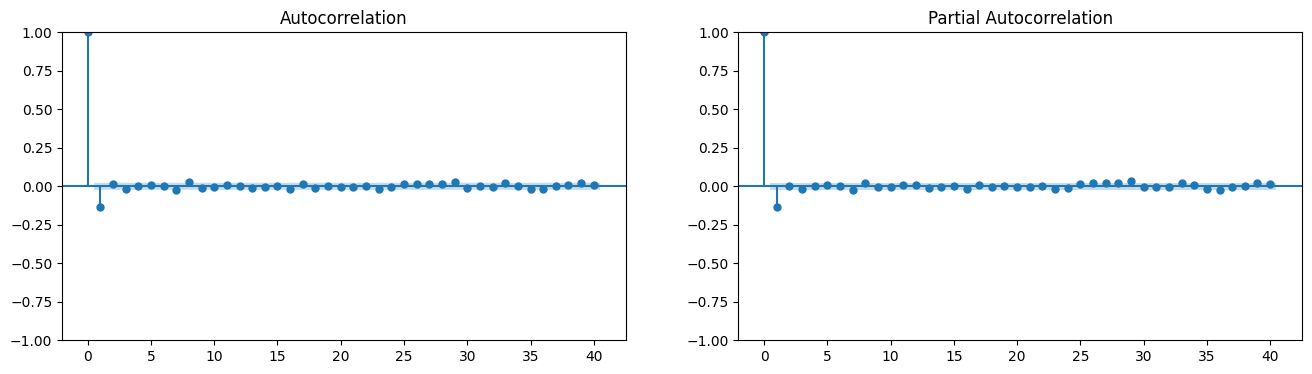

In [8]:
# ACF and PACF plots for parameter estimation
fig, axes = plt.subplots(1, 2, figsize=(16, 4))
plot_acf(df_diff, ax=axes[0], lags=40)
plot_pacf(df_diff, ax=axes[1], lags=40)
plt.show()

In [9]:
# Train-Test Split (80% training)
train_size = int(len(df) * 0.8)
train, test = df.iloc[:train_size], df.iloc[train_size:]

In [10]:
# Fit ARIMA model (p=1, d=1, q=1)
arima_model = ARIMA(train['Ex_rate'], order=(1, 1, 1))
arima_fit = arima_model.fit()
print(arima_fit.summary())



/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:                Ex_rate   No. Observations:                 6070
Model:                 ARIMA(1, 1, 1)   Log Likelihood               22719.046
Date:                Sat, 11 Apr 2026   AIC                         -45432.092
Time:                        12:19:04   BIC                         -45411.959
Sample:                    01-01-1990   HQIC                        -45425.104
                         - 08-14-2006                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.5972      0.062     -9.648      0.000      -0.719      -0.476
ma.L1          0.5398      0.064      8.430      0.000       0.414       0.665
sigma2      3.281e-05   1.95e-07    168.198      0.0

In [11]:
arima_forecast = arima_fit.forecast(steps=len(test))

In [12]:
# Using Holt's Linear Trend model (Trend='add', No Seasonality)
es_model = ExponentialSmoothing(train['Ex_rate'], trend='add', seasonal=None)
es_fit = es_model.fit()
es_forecast = es_fit.forecast(steps=len(test))

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


In [13]:
def compute_metrics(actual, forecast):
    mae = mean_absolute_error(actual, forecast)
    rmse = np.sqrt(mean_squared_error(actual, forecast))
    mape = np.mean(np.abs((actual - forecast) / actual)) * 100
    return mae, rmse, mape

mae_a, rmse_a, mape_a = compute_metrics(test['Ex_rate'], arima_forecast)
mae_e, rmse_e, mape_e = compute_metrics(test['Ex_rate'], es_forecast)

print(f"\nARIMA Evaluation -> MAE: {mae_a:.4f}, RMSE: {rmse_a:.4f}, MAPE: {mape_a:.2f}%")
print(f"Exp. Smoothing Evaluation -> MAE: {mae_e:.4f}, RMSE: {rmse_e:.4f}, MAPE: {mape_e:.2f}%")


ARIMA Evaluation -> MAE: 0.1777, RMSE: 0.2054, MAPE: 22.80%
Exp. Smoothing Evaluation -> MAE: 0.2066, RMSE: 0.2391, MAPE: 26.51%


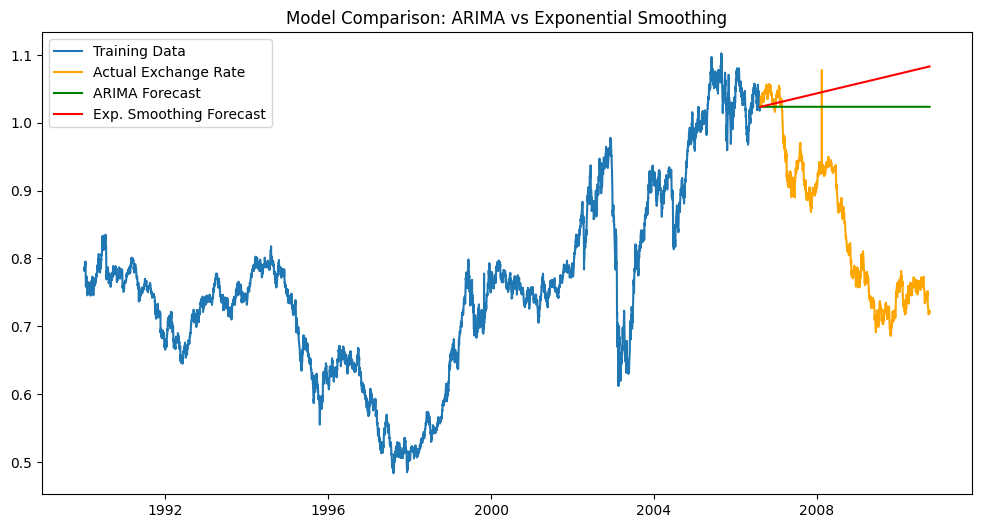

In [14]:
# Visualize Forecasts
plt.figure(figsize=(12, 6))
plt.plot(train.index, train['Ex_rate'], label='Training Data')
plt.plot(test.index, test['Ex_rate'], label='Actual Exchange Rate', color='orange')
plt.plot(test.index, arima_forecast, label='ARIMA Forecast', color='green')
plt.plot(test.index, es_forecast, label='Exp. Smoothing Forecast', color='red')
plt.title('Model Comparison: ARIMA vs Exponential Smoothing')
plt.legend()
plt.show()